# Experiment 9: Classes and Objects

## 🟢 THE MATRIX ARC — Part IX: *The Architect's Blueprint*

Deep in a room of screens, the Architect reveals the truth: every Agent, every human construct, was built from a blueprint — a class — instantiated over and over into countless objects.

```mermaid
flowchart LR
    E1["1. Basics"]
    E2["2. Operators"]
    E3["3. Conditionals"]
    E4["4. Loops"]
    E5["5. Strings/Sets"]
    E6["6. Lists/Dict"]
    E7["7. Functions"]
    E8["8. Files/Errors"]
    E9["9. Classes"]
    E10["10. Data Viz"]
    E1 --> E2
    E2 --> E3
    E3 --> E4
    E4 --> E5
    E5 --> E6
    E6 --> E7
    E7 --> E8
    E8 --> E9
    E9 --> E10
    class E9 current;
    classDef current fill:#00ff41,stroke:#003b00,stroke-width:3px,color:#000,font-weight:bold;
```

### 🗒️ What This Notebook Covers
<div class="alert alert-block alert-info">
<b>In this notebook you will:</b> build a <code>Student</code> class, add methods and a class-average function, demonstrate single/multilevel/multiple inheritance, override a method, and overload the <code>+</code> operator on a <code>Point</code> class.
</div>

<!-- python-lab-visual: experiment_09_classes_objects.png -->

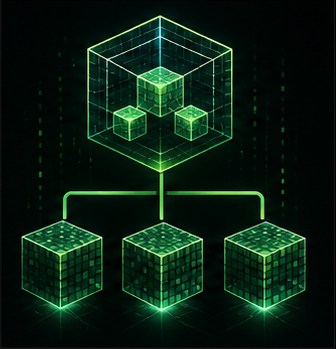

## 🎯 Aim

<div class="alert alert-block alert-info">
<b>Aim:</b> To design classes and objects, and to implement encapsulation, inheritance (single, multilevel, multiple), method overriding, and operator overloading.
</div>

## 🧩 Python Concepts Used

- Classes, `__init__`, and objects
- Instance methods and attributes
- Inheritance: single, multilevel, multiple
- Method overriding
- Operator overloading (`__add__`)

## Question 1: One Blueprint, Three Instances

### 📋 Problem Statement
> Create a `Student` class with `name`, `sap_id`, and marks in `phy`, `chem`, `maths`. Create 3 objects and display all student details.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Every object inside the Matrix is built from a blueprint. A `Student` class defines what every student *is*, and three separate objects are instantiated from that one template.
</div>

### 🔄 Workflow
```mermaid
classDiagram
    class Student {
        +name
        +sap_id
        +marks
        +display()
    }
    Student --> "riya" : instance
    Student --> "kunal" : instance
    Student --> "meera" : instance
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> `__init__` runs once per object, so each `Student` instance gets its own independent copy of `name`, `sap_id`, and `marks`.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [1]:
class Student:
    def __init__(self, name, sap_id, marks):
        self.name = name
        self.sap_id = sap_id
        self.marks = marks

    def display(self):
        print(f"Name: {self.name}, SAP ID: {self.sap_id}, Marks: {self.marks}")


students = [
    Student("Riya", "5001", {"phy": 78, "chem": 67, "maths": 81}),
    Student("Kunal", "5002", {"phy": 88, "chem": 92, "maths": 85}),
    Student("Meera", "5003", {"phy": 69, "chem": 73, "maths": 64}),
]

for student in students:
    student.display()

Name: Riya, SAP ID: 5001, Marks: {'phy': 78, 'chem': 67, 'maths': 81}
Name: Kunal, SAP ID: 5002, Marks: {'phy': 88, 'chem': 92, 'maths': 85}
Name: Meera, SAP ID: 5003, Marks: {'phy': 69, 'chem': 73, 'maths': 64}


## Question 2: Individual and Collective Statistics

### 📋 Problem Statement
> Add constructor-based initialization plus `display()`, `marks_percentage()`, and `result()` methods; also write a function to find the class average.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> The blueprint gets more capable: methods to display, compute percentage, and decide pass/fail — plus a standalone function that averages across every object at once.
</div>

### 📐 Formula
$$percentage_i = \dfrac{\sum marks_i}{\text{subject count}}, \qquad \overline{class} = \dfrac{\sum_i percentage_i}{\text{student count}}$$

### 🔄 Workflow
```mermaid
flowchart TD
    A["StudentRecord objects"] --> B["record.marks_percentage()"]
    A --> C["record.result()"]
    B --> D["class_average(records)"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> `class_average()` operates on a *list* of objects, showing how object-oriented code moves smoothly between an individual's data and a group statistic.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [2]:
class StudentRecord:
    def __init__(self, name, sap_id, marks):
        self.name = name
        self.sap_id = sap_id
        self.marks = marks

    def display(self):
        print(f"Name: {self.name} | SAP ID: {self.sap_id} | Marks: {self.marks}")

    def marks_percentage(self):
        return sum(self.marks.values()) / len(self.marks)

    def result(self):
        return "Pass" if all(mark > 40 for mark in self.marks.values()) else "Fail"


def class_average(records):
    return sum(record.marks_percentage() for record in records) / len(records)


input_data = [
    ("Riya", "5001", {"phy": 78, "chem": 67, "maths": 81}),
    ("Kunal", "5002", {"phy": 88, "chem": 92, "maths": 85}),
    ("Meera", "5003", {"phy": 39, "chem": 73, "maths": 64}),
]

records = [StudentRecord(name, sap_id, marks) for name, sap_id, marks in input_data]

for record in records:
    record.display()
    print("Percentage:", f"{record.marks_percentage():.2f}%")
    print("Result:", record.result())
    print("-" * 45)

print("Class average percentage:", f"{class_average(records):.2f}%")

Name: Riya | SAP ID: 5001 | Marks: {'phy': 78, 'chem': 67, 'maths': 81}
Percentage: 75.33%
Result: Pass
---------------------------------------------
Name: Kunal | SAP ID: 5002 | Marks: {'phy': 88, 'chem': 92, 'maths': 85}
Percentage: 88.33%
Result: Pass
---------------------------------------------
Name: Meera | SAP ID: 5003 | Marks: {'phy': 39, 'chem': 73, 'maths': 64}
Percentage: 58.67%
Result: Fail
---------------------------------------------
Class average percentage: 74.11%


## Question 3: Three Lines of Descent

### 📋 Problem Statement
> Create programs to implement single, multilevel, and multiple inheritance.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Agent Smith didn't stay a single isolated program — he learned to replicate onto others. This demonstrates the three ways a class can inherit from another.
</div>

### 🔄 Workflow
```mermaid
classDiagram
    Person <|-- Teacher
    Animal <|-- Mammal
    Mammal <|-- Dog
    Writer <|-- AuthorSpeaker
    Speaker <|-- AuthorSpeaker
    class Person { +introduce() }
    class Teacher { +subject() }
    class Animal { +breathe() }
    class Mammal { +feed_milk() }
    class Dog { +bark() }
    class Writer { +write() }
    class Speaker { +speak() }
    class AuthorSpeaker
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> `Dog` automatically has access to `breathe()` (from `Animal`) and `feed_milk()` (from `Mammal`) without redefining either — that's multilevel inheritance at work.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [3]:
# Single inheritance
class Person:
    def introduce(self):
        print("I am a person.")


class Teacher(Person):
    def subject(self):
        print("I teach Python.")


# Multilevel inheritance
class Animal:
    def breathe(self):
        print("Breathing...")


class Mammal(Animal):
    def feed_milk(self):
        print("Feeding milk...")


class Dog(Mammal):
    def bark(self):
        print("Woof!")


# Multiple inheritance
class Writer:
    def write(self):
        print("Writing an article.")


class Speaker:
    def speak(self):
        print("Speaking at an event.")


class AuthorSpeaker(Writer, Speaker):
    pass


print("Single Inheritance:")
t = Teacher()
t.introduce()
t.subject()

print("\nMultilevel Inheritance:")
d = Dog()
d.breathe()
d.feed_milk()
d.bark()

print("\nMultiple Inheritance:")
as_role = AuthorSpeaker()
as_role.write()
as_role.speak()

Single Inheritance:
I am a person.
I teach Python.

Multilevel Inheritance:
Breathing...
Feeding milk...
Woof!

Multiple Inheritance:
Writing an article.
Speaking at an event.


## Question 4: Smith's Rebellion

### 📋 Problem Statement
> Create a class to implement method overriding.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Overriding is Smith's rebellion in code form: a child class keeps the same method name as its parent but replaces the behavior underneath.
</div>

### 🔄 Workflow
```mermaid
classDiagram
    Shape <|-- Rectangle
    class Shape {
        +describe()
        +area() 0
    }
    class Rectangle {
        +describe() overridden
        +area() length × breadth
    }
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Python resolves `rectangle.describe()` to `Rectangle`'s version at runtime — the parent's method still exists but is shadowed, not deleted.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [4]:
class Shape:
    def describe(self):
        print("This is a generic shape.")

    def area(self):
        return 0


class Rectangle(Shape):
    def __init__(self, length, breadth):
        self.length = length
        self.breadth = breadth

    def describe(self):
        print("This is a rectangle.")

    def area(self):
        return self.length * self.breadth


shape = Shape()
rectangle = Rectangle(10, 5)

shape.describe()
print("Shape area:", shape.area())

rectangle.describe()
print("Rectangle area:", rectangle.area())

This is a generic shape.
Shape area: 0
This is a rectangle.
Rectangle area: 50


## Question 5: Redefining +

### 📋 Problem Statement
> Create a class for operator overloading that adds two `Point` objects, each having `x` and `y` values.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Operator overloading teaches a custom `Point` object what `+` should mean — combining two coordinates the way two allied programs might merge their capabilities.
</div>

### 📐 Formula
$$P_3 = P_1 + P_2 \implies (x_3,y_3) = (x_1+x_2,\ y_1+y_2)$$

### 🔄 Workflow
```mermaid
flowchart LR
    A["P1(10,20)"] --> C["__add__()"]
    B["P2(12,15)"] --> C
    C --> D["P3(22,35)"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Defining `__add__` is what lets Python's built-in `+` symbol work on a completely custom class — one of the 'dunder' methods that hook into the language itself.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [5]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __add__(self, other):
        if not isinstance(other, Point):
            return NotImplemented
        return Point(self.x + other.x, self.y + other.y)

    def __repr__(self):
        return f"Point(x={self.x}, y={self.y})"


p1 = Point(10, 20)
p2 = Point(12, 15)
p3 = p1 + p2

print("P1:", p1)
print("P2:", p2)
print("P3 = P1 + P2:", p3)

P1: Point(x=10, y=20)
P2: Point(x=12, y=15)
P3 = P1 + P2: Point(x=22, y=35)


## 🌟 Original Extension: Extending Point With Subtraction and Equality

<div class="alert alert-block alert-info">
<b>💡 Why this extension:</b> Q5 only overloads `+` on the `Point` class. This extension adds `__sub__` and `__eq__` so the same class supports subtraction and meaningful equality comparison too.
</div>

### 🔧 What It Adds

<div class="alert alert-block alert-success">
<b>New capability:</b> Shows that operator overloading isn't limited to one operator — the same technique from Q5 extends cleanly to `-` and `==` on the identical class.
</div>

In [6]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __add__(self, other):
        return Point(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        return Point(self.x - other.x, self.y - other.y)

    def __eq__(self, other):
        return isinstance(other, Point) and self.x == other.x and self.y == other.y

    def __repr__(self):
        return f"Point(x={self.x}, y={self.y})"


p1 = Point(10, 20)
p2 = Point(12, 15)

print("P1 - P2:", p1 - p2)
print("P1 == Point(10, 20)?", p1 == Point(10, 20))
print("P1 == P2?", p1 == p2)

P1 - P2: Point(x=-2, y=5)
P1 == Point(10, 20)? True
P1 == P2? False


## 📝 Conclusion

<div class="alert alert-block alert-success">
<b>📝 Conclusion:</b> This experiment implemented classes, objects, and all three forms of inheritance, along with method overriding and operator overloading. It demonstrated how OOP lets related data and behavior be organized, reused, and extended cleanly.
</div>

### 🗺️ Where You Are in the Arc

```mermaid
flowchart LR
    E1["1. Basics"]
    E2["2. Operators"]
    E3["3. Conditionals"]
    E4["4. Loops"]
    E5["5. Strings/Sets"]
    E6["6. Lists/Dict"]
    E7["7. Functions"]
    E8["8. Files/Errors"]
    E9["9. Classes"]
    E10["10. Data Viz"]
    E1 --> E2
    E2 --> E3
    E3 --> E4
    E4 --> E5
    E5 --> E6
    E6 --> E7
    E7 --> E8
    E8 --> E9
    E9 --> E10
    class E9 current;
    classDef current fill:#00ff41,stroke:#003b00,stroke-width:3px,color:#000,font-weight:bold;
```